# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Chargement de la lib Rust
import ctypes
import os

lib_path = os.path.join(os.getcwd(), "ml_lib/target/debug/libml_lib.dylib")
ml_lib = ctypes.cdll.LoadLibrary(lib_path)

In [3]:
# Declaration des types des fonctions Rust

# Modele Lineaire
ml_lib.create_linear_model.argtypes = [ctypes.c_size_t, ctypes.c_float]
ml_lib.create_linear_model.restype  = ctypes.c_void_p
ml_lib.train_step.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.c_float]
ml_lib.train_step.restype  = None
ml_lib.predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.predict.restype  = ctypes.c_float
ml_lib.free_linear_model.argtypes = [ctypes.c_void_p]
ml_lib.free_linear_model.restype  = None
ml_lib.save_linear_model.argtypes = [ctypes.c_void_p, ctypes.c_char_p]
ml_lib.save_linear_model.restype  = None
ml_lib.load_linear_model.argtypes = [ctypes.c_char_p]
ml_lib.load_linear_model.restype  = ctypes.c_void_p

# PMC
ml_lib.create_pmc.argtypes = [ctypes.c_size_t, ctypes.c_size_t, ctypes.c_size_t, ctypes.c_float]
ml_lib.create_pmc.restype = ctypes.c_void_p
ml_lib.pmc_train_step.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.pmc_train_step.restype = None
ml_lib.pmc_predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float)]
ml_lib.pmc_predict.restype = None
ml_lib.free_pmc.argtypes = [ctypes.c_void_p]
ml_lib.free_pmc.restype = None
ml_lib.save_pmc.argtypes = [ctypes.c_void_p, ctypes.c_char_p]
ml_lib.save_pmc.restype  = None
ml_lib.load_pmc.argtypes = [ctypes.c_char_p]
ml_lib.load_pmc.restype  = ctypes.c_void_p

# RBFN
ml_lib.create_rbfn.argtypes = [ctypes.c_size_t, ctypes.c_size_t, ctypes.c_size_t, ctypes.c_float, ctypes.c_float]
ml_lib.create_rbfn.restype = ctypes.c_void_p
ml_lib.rbfn_set_centers.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.rbfn_set_centers.restype = None
ml_lib.rbfn_train_step.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.rbfn_train_step.restype = None
ml_lib.rbfn_predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float)]
ml_lib.rbfn_predict.restype = None
ml_lib.free_rbfn.argtypes = [ctypes.c_void_p]
ml_lib.free_rbfn.restype = None
ml_lib.save_rbfn.argtypes = [ctypes.c_void_p, ctypes.c_char_p]
ml_lib.save_rbfn.restype  = None
ml_lib.load_rbfn.argtypes = [ctypes.c_char_p]
ml_lib.load_rbfn.restype  = ctypes.c_void_p

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [4]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

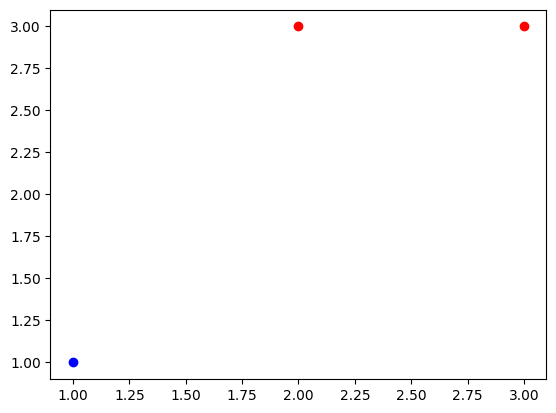

<Figure size 640x480 with 0 Axes>

In [5]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

In [6]:
N = 2
lr = 0.01
epochs = 1000

model = ml_lib.create_linear_model(N, ctypes.c_float(lr))

for epoch in range(epochs):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Entrainement termine")

Entrainement termine


In [7]:
# On vérifie que le modèle classe bien les 3 points
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    prediction = ml_lib.predict(model, x_ptr, N)
    classe = "bleu" if prediction >= 0 else "rouge"
    vraie_classe = "bleu" if Y[i] == 1 else "rouge"
    correct = "OK" if classe == vraie_classe else "KO"
    print(f"Point {X[i]} → prédit : {classe} | vrai : {vraie_classe} | {correct}")

ml_lib.free_linear_model(model)

Point [1 1] → prédit : bleu | vrai : bleu | OK
Point [2 3] → prédit : rouge | vrai : rouge | OK
Point [3 3] → prédit : rouge | vrai : rouge | OK


In [8]:
# RBFN sur Linear Simple
# Centres initialises avec les 3 points du dataset
N = 2
hidden_size = 3
rbfn_ls = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(2.0), ctypes.c_float(0.1))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_ls, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_ls, x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_ls, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score RBFN sur Linear Simple : {correct}/{len(X)} correct")
ml_lib.free_rbfn(rbfn_ls)

Score RBFN sur Linear Simple : 3/3 correct


In [9]:
### # Test sauvegarde et chargement du modele lineaire
# On entraine un modele puis on le sauvegarde
N = 2
model_save = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_save, x_ptr, N, ctypes.c_float(float(Y[i])))

# Sauvegarde
ml_lib.save_linear_model(model_save, b"model_lineaire.bin")
print("Modele sauvegarde dans model_lineaire.bin")
ml_lib.free_linear_model(model_save)

# Chargement
model_load = ml_lib.load_linear_model(b"model_lineaire.bin")
print("Modele charge depuis model_lineaire.bin")

# Verification
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_load, x_ptr, N)
    classe = "bleu" if pred >= 0 else "rouge"
    print(f"Point {X[i]} → {classe}")

ml_lib.free_linear_model(model_load)

Modele sauvegarde dans model_lineaire.bin
Modele charge depuis model_lineaire.bin
Point [1 1] → bleu
Point [2 3] → rouge
Point [3 3] → rouge


### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [10]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

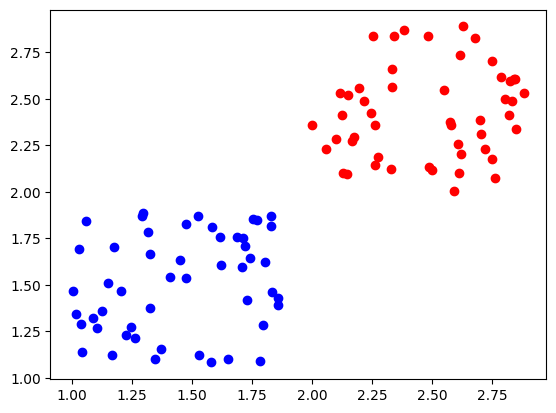

<Figure size 640x480 with 0 Axes>

In [11]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

In [12]:
# Entrainement modele lineaire sur Linear Multiple
# 100 points : 50 bleus et 50 rouges
N = 2
model_lm = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_lm, x_ptr, N, ctypes.c_float(float(Y[i].item())))

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_lm, x_ptr, N)
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score : {correct}/{len(X)} correct")
ml_lib.free_linear_model(model_lm)

Score : 99/100 correct


In [13]:
# RBFN sur Linear Multiple
# On initialise les centres avec des points du dataset - mieux que l'aleatoire
N = 2
hidden_size = 10
rbfn_lm = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

# On prend les 10 premiers points comme centres
centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_lm, centers_ptr, len(centers))

for epoch in range(5000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i].item())], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_lm, x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_lm, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score RBFN sur Linear Multiple : {correct}/{len(X)} correct")
ml_lib.free_rbfn(rbfn_lm)

Score RBFN sur Linear Multiple : 99/100 correct


### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [14]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

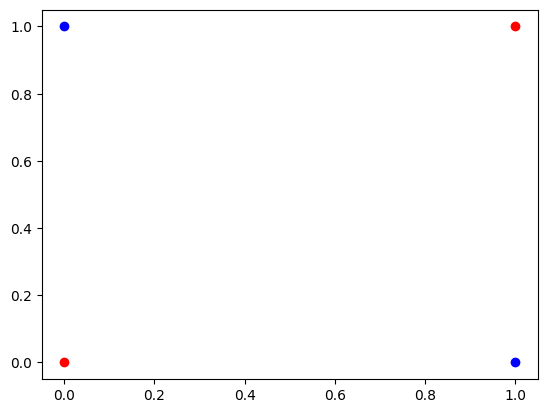

<Figure size 640x480 with 0 Axes>

In [15]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

In [16]:
# Je teste le modele lineaire sur XOR
# Je sais d'avance qu'il va echouer car une droite ne peut pas separer ces 4 points
N = 2
model_xor = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_xor, x_ptr, N, ctypes.c_float(float(Y[i])))

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_xor, x_ptr, N)
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score : {correct}/{len(X)} correct")
ml_lib.free_linear_model(model_xor)

Score : 2/4 correct


In [17]:
# Le modele lineaire echoue sur le XOR
# Je teste maintenant avec le PMC (2 entrees, 4 neurones caches, 1 sortie)
N = 2
pmc_xor = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.1))

for epoch in range(100000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.pmc_train_step(pmc_xor, x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.pmc_predict(pmc_xor, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0.5 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score PMC sur XOR : {correct}/{len(X)} correct")
ml_lib.free_pmc(pmc_xor)

Score PMC sur XOR : 4/4 correct


In [18]:
### # RBFN sur XOR
# Centres initialises avec les 4 points du dataset
N = 2
hidden_size = 4
rbfn_xor = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(2.0), ctypes.c_float(0.1))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_xor, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_xor, x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_xor, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score RBFN sur XOR : {correct}/{len(X)} correct")
ml_lib.free_rbfn(rbfn_xor)

Score RBFN sur XOR : 4/4 correct


In [19]:
### # Test sauvegarde et chargement du PMC
# On entraine le PMC sur XOR puis on le sauvegarde
N = 2
pmc_save = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.1))

for epoch in range(100000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.pmc_train_step(pmc_save, x_ptr, N, y_ptr, 1)

ml_lib.save_pmc(pmc_save, b"pmc_xor.bin")
print("PMC sauvegarde dans pmc_xor.bin")
ml_lib.free_pmc(pmc_save)

# Chargement et verification
pmc_load = ml_lib.load_pmc(b"pmc_xor.bin")
print("PMC charge depuis pmc_xor.bin")

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.pmc_predict(pmc_load, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0.5 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score apres chargement : {correct}/{len(X)} correct")
ml_lib.free_pmc(pmc_load)

PMC sauvegarde dans pmc_xor.bin
PMC charge depuis pmc_xor.bin
Score apres chargement : 4/4 correct


In [20]:
### # Test sauvegarde et chargement du RBFN sur XOR
N = 2
hidden_size = 4
rbfn_save = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(2.0), ctypes.c_float(0.1))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_save, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_save, x_ptr, N, y_ptr, 1)

ml_lib.save_rbfn(rbfn_save, b"rbfn_xor.bin")
print("RBFN sauvegarde dans rbfn_xor.bin")
ml_lib.free_rbfn(rbfn_save)

# Chargement
rbfn_load = ml_lib.load_rbfn(b"rbfn_xor.bin")
print("RBFN charge depuis rbfn_xor.bin")

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_load, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score apres chargement : {correct}/{len(X)} correct")
ml_lib.free_rbfn(rbfn_load)

RBFN sauvegarde dans rbfn_xor.bin
RBFN charge depuis rbfn_xor.bin
Score apres chargement : 4/4 correct


























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [21]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

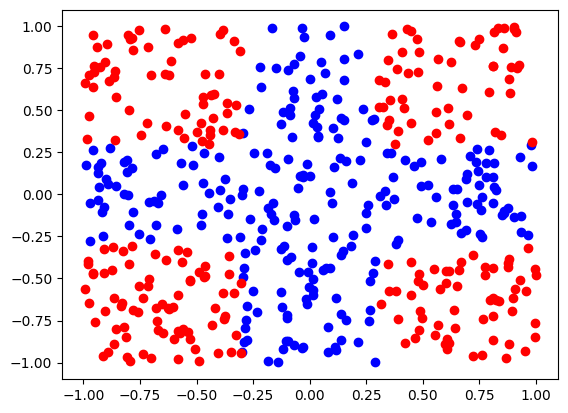

<Figure size 640x480 with 0 Axes>

In [22]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

In [23]:
# Le modele lineaire va echouer sur le Cross
# Les points bleus forment une croix - impossible a separer par une droite
N = 2
model_cross = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_cross, x_ptr, N, ctypes.c_float(float(Y[i])))

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_cross, x_ptr, N)
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score modele lineaire sur Cross : {correct}/{len(X)} correct")
ml_lib.free_linear_model(model_cross)

Score modele lineaire sur Cross : 207/500 correct


In [24]:
# Le PMC avec 4 neurones caches resout le Cross
N = 2
pmc_cross = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.pmc_train_step(pmc_cross, x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.pmc_predict(pmc_cross, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0.5 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score PMC sur Cross : {correct}/{len(X)} correct")
ml_lib.free_pmc(pmc_cross)

Score PMC sur Cross : 440/500 correct


In [25]:
### # RBFN sur Cross
# Centres initialises avec 20 points du dataset
N = 2
hidden_size = 20
rbfn_cross = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(2.0), ctypes.c_float(0.01))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_cross, centers_ptr, len(centers))

for epoch in range(5000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_cross, x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_cross, x_ptr, N, out_ptr)
    pred = 1 if output[0] >= 0 else -1
    if (pred >= 0 and Y[i] == 1) or (pred < 0 and Y[i] == -1):
        correct += 1

print(f"Score RBFN sur Cross : {correct}/{len(X)} correct")
ml_lib.free_rbfn(rbfn_cross)

Score RBFN sur Cross : 478/500 correct


### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [26]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

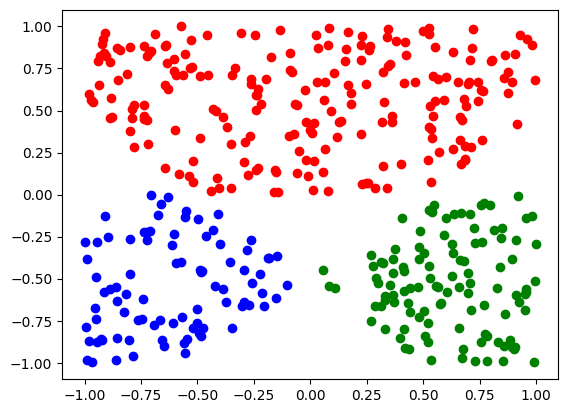

<Figure size 640x480 with 0 Axes>

In [27]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [28]:
# Multi Linear 3 classes - approche OVR (One Versus Rest)
# On entraine 3 modeles lineaires - un par classe
# Modele 1 : bleu vs reste
# Modele 2 : rouge vs reste
# Modele 3 : vert vs reste
N = 2
nb_classes = 3
modeles = []

for k in range(nb_classes):
    m = ml_lib.create_linear_model(N, ctypes.c_float(0.01))
    modeles.append(m)

for epoch in range(1000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        for k in range(nb_classes):
            ml_lib.train_step(modeles[k], x_ptr, N, ctypes.c_float(float(Y[i][k])))

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    scores = [ml_lib.predict(modeles[k], x_ptr, N) for k in range(nb_classes)]
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print(f"Score modele lineaire multi-classes : {correct}/{len(X)} correct")

for m in modeles:
    ml_lib.free_linear_model(m)

Score modele lineaire multi-classes : 406/409 correct


In [29]:
### # RBFN sur Multi Linear 3 classes - OVR
N = 2
nb_classes = 3
hidden_size = 15
rbfn_modeles = []

for k in range(nb_classes):
    m = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))
    centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
    centers_ptr = np.ctypeslib.as_ctypes(centers)
    ml_lib.rbfn_set_centers(m, centers_ptr, len(centers))
    rbfn_modeles.append(m)

for epoch in range(2000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        for k in range(nb_classes):
            y = np.array([float(Y[i][k])], dtype=np.float32)
            y_ptr = np.ctypeslib.as_ctypes(y)
            ml_lib.rbfn_train_step(rbfn_modeles[k], x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    scores = []
    for k in range(nb_classes):
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.rbfn_predict(rbfn_modeles[k], x_ptr, N, out_ptr)
        scores.append(output[0])
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print(f"Score RBFN Multi Linear : {correct}/{len(X)} correct")
for m in rbfn_modeles:
    ml_lib.free_rbfn(m)

Score RBFN Multi Linear : 409/409 correct


### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [30]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

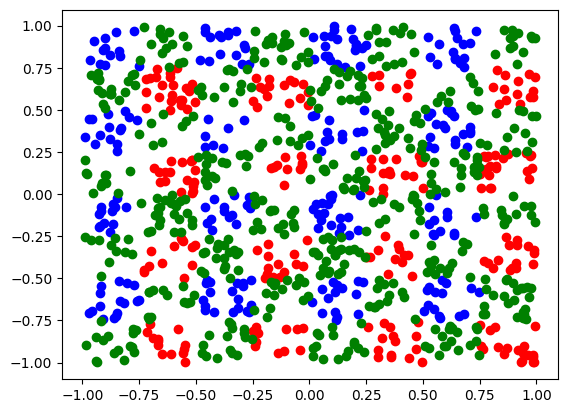

<Figure size 640x480 with 0 Axes>

In [31]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [32]:
# Multi Cross - le modele lineaire va echouer
# Les 3 classes sont melangees - impossible a separer par des droites
N = 2
nb_classes = 3
modeles_cross = []

for k in range(nb_classes):
    m = ml_lib.create_linear_model(N, ctypes.c_float(0.01))
    modeles_cross.append(m)

for epoch in range(1000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        for k in range(nb_classes):
            ml_lib.train_step(modeles_cross[k], x_ptr, N, ctypes.c_float(float(Y[i][k])))

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    scores = [ml_lib.predict(modeles_cross[k], x_ptr, N) for k in range(nb_classes)]
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print(f"Score modele lineaire Multi Cross : {correct}/{len(X)} correct")

for m in modeles_cross:
    ml_lib.free_linear_model(m)

Score modele lineaire Multi Cross : 504/1000 correct


In [33]:
# Le PMC resout le Multi Cross avec 3 sorties
N = 2
nb_classes = 3
pmc_multi = ml_lib.create_pmc(N, 16, nb_classes, ctypes.c_float(0.1))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array(Y[i], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.pmc_train_step(pmc_multi, x_ptr, N, y_ptr, nb_classes)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(nb_classes, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.pmc_predict(pmc_multi, x_ptr, N, out_ptr)
    classe_predite = int(np.argmax(output))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print(f"Score PMC Multi Cross : {correct}/{len(X)} correct")
ml_lib.free_pmc(pmc_multi)

Score PMC Multi Cross : 596/1000 correct


In [34]:
### # RBFN sur Multi Cross - 3 classes melangees
N = 2
nb_classes = 3
hidden_size = 30
rbfn_multi = []

for k in range(nb_classes):
    m = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(2.0), ctypes.c_float(0.01))
    centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
    centers_ptr = np.ctypeslib.as_ctypes(centers)
    ml_lib.rbfn_set_centers(m, centers_ptr, len(centers))
    rbfn_multi.append(m)

for epoch in range(5000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        for k in range(nb_classes):
            y = np.array([float(Y[i][k])], dtype=np.float32)
            y_ptr = np.ctypeslib.as_ctypes(y)
            ml_lib.rbfn_train_step(rbfn_multi[k], x_ptr, N, y_ptr, 1)

correct = 0
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    scores = []
    for k in range(nb_classes):
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.rbfn_predict(rbfn_multi[k], x_ptr, N, out_ptr)
        scores.append(output[0])
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print(f"Score RBFN Multi Cross : {correct}/{len(X)} correct")
for m in rbfn_multi:
    ml_lib.free_rbfn(m)

Score RBFN Multi Cross : 517/1000 correct


## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [35]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

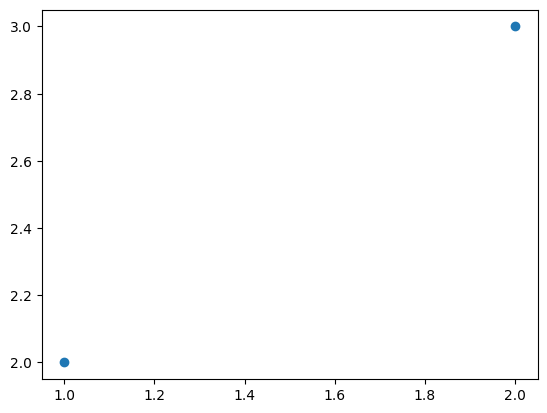

<Figure size 640x480 with 0 Axes>

In [36]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [37]:
# Regression Linear Simple 2D
# X a 1 feature, Y est un nombre continu
# Le modele doit apprendre que Y = X + 1
N = 1
model_reg = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_reg, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Predictions du modele lineaire :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_reg, x_ptr, N)
    print(f"X={X[i][0]} → predit={pred:.3f} | vrai={Y[i]}")

x_test = np.array([1.5], dtype=np.float32)
x_ptr = np.ctypeslib.as_ctypes(x_test)
pred_test = ml_lib.predict(model_reg, x_ptr, N)
print(f"X=1.5 → predit={pred_test:.3f} | vrai attendu=2.5")

ml_lib.free_linear_model(model_reg)

Predictions du modele lineaire :
X=1 → predit=2.000 | vrai=2
X=2 → predit=3.000 | vrai=3
X=1.5 → predit=2.500 | vrai attendu=2.5


In [38]:
### # RBFN sur Regression Linear Simple 2D
N = 1
hidden_size = 2
rbfn_reg = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_reg, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_reg, x_ptr, N, y_ptr, 1)

print("RBFN sur Regression Linear Simple 2D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_reg, x_ptr, N, out_ptr)
    print(f"X={X[i][0]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_rbfn(rbfn_reg)

RBFN sur Regression Linear Simple 2D :
X=1 → predit=2.000 | vrai=2
X=2 → predit=3.000 | vrai=3


### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [39]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

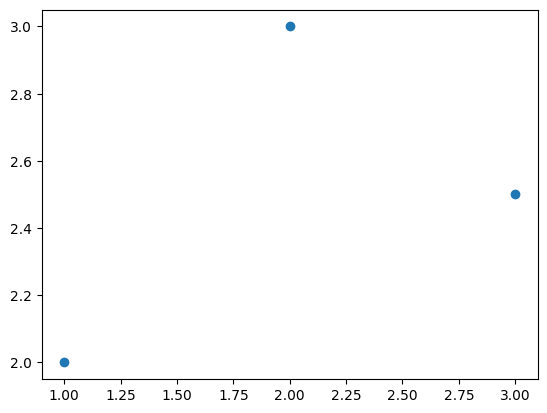

<Figure size 640x480 with 0 Axes>

In [40]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [41]:
# Regression Non Lineaire Simple 2D
# 3 points - la relation n'est pas une droite parfaite
N = 1
model_reg2 = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_reg2, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Modele lineaire sur Non Linear 2D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_reg2, x_ptr, N)
    print(f"X={X[i][0]} → predit={pred:.3f} | vrai={Y[i]}")

ml_lib.free_linear_model(model_reg2)

Modele lineaire sur Non Linear 2D :
X=1 → predit=2.257 | vrai=2.0
X=2 → predit=2.494 | vrai=3.0
X=3 → predit=2.731 | vrai=2.5


In [42]:
# Le PMC avec 7 neurones caches va mieux s'en sortir sur ce cas non lineaire
N = 1
pmc_reg2 = ml_lib.create_pmc(N, 7, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.pmc_train_step(pmc_reg2, x_ptr, N, y_ptr, 1)

print("PMC sur Non Linear 2D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.pmc_predict(pmc_reg2, x_ptr, N, out_ptr)
    print(f"X={X[i][0]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_pmc(pmc_reg2)

PMC sur Non Linear 2D :
X=1 → predit=2.000 | vrai=2.0
X=2 → predit=3.000 | vrai=3.0
X=3 → predit=2.500 | vrai=2.5


In [43]:
### # RBFN sur Regression Non Linear Simple 2D
N = 1
hidden_size = 3
rbfn_reg2 = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_reg2, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_reg2, x_ptr, N, y_ptr, 1)

print("RBFN sur Non Linear Simple 2D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_reg2, x_ptr, N, out_ptr)
    print(f"X={X[i][0]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_rbfn(rbfn_reg2)

RBFN sur Non Linear Simple 2D :
X=1 → predit=2.000 | vrai=2.0
X=2 → predit=3.000 | vrai=3.0
X=3 → predit=2.500 | vrai=2.5


### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [44]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [45]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [46]:
# Regression Linear Simple 3D - 2 features en entree
N = 2
model_3d = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_3d, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Modele lineaire sur Linear Simple 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_3d, x_ptr, N)
    print(f"X={X[i]} → predit={pred:.3f} | vrai={Y[i]}")

ml_lib.free_linear_model(model_3d)

Modele lineaire sur Linear Simple 3D :
X=[1 1] → predit=2.000 | vrai=2.0
X=[2 2] → predit=3.000 | vrai=3.0
X=[3 1] → predit=2.500 | vrai=2.5


In [47]:
### # RBFN sur Linear Simple 3D
N = 2
hidden_size = 3
rbfn_3d = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_3d, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_3d, x_ptr, N, y_ptr, 1)

print("RBFN sur Linear Simple 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_3d, x_ptr, N, out_ptr)
    print(f"X={X[i]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_rbfn(rbfn_3d)

RBFN sur Linear Simple 3D :
X=[1 1] → predit=2.000 | vrai=2.0
X=[2 2] → predit=3.000 | vrai=3.0
X=[3 1] → predit=2.500 | vrai=2.5


### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [48]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [49]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [50]:
# Regression Linear Tricky 3D
N = 2
model_tricky = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_tricky, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Modele lineaire sur Linear Tricky 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_tricky, x_ptr, N)
    print(f"X={X[i]} → predit={pred:.3f} | vrai={Y[i]}")

ml_lib.free_linear_model(model_tricky)

Modele lineaire sur Linear Tricky 3D :
X=[1 1] → predit=1.000 | vrai=1
X=[2 2] → predit=2.000 | vrai=2
X=[3 3] → predit=3.000 | vrai=3


In [51]:
### # RBFN sur Linear Tricky 3D
N = 2
hidden_size = 3
rbfn_tricky = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_tricky, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_tricky, x_ptr, N, y_ptr, 1)

print("RBFN sur Linear Tricky 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_tricky, x_ptr, N, out_ptr)
    print(f"X={X[i]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_rbfn(rbfn_tricky)

RBFN sur Linear Tricky 3D :
X=[1 1] → predit=1.000 | vrai=1
X=[2 2] → predit=2.000 | vrai=2
X=[3 3] → predit=3.000 | vrai=3


### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [5]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [6]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
# Non Linear Simple 3D - le modele lineaire va echouer
N = 2
model_nl3d = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model_nl3d, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Modele lineaire sur Non Linear Simple 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    pred = ml_lib.predict(model_nl3d, x_ptr, N)
    print(f"X={X[i]} → predit={pred:.3f} | vrai={Y[i]}")

ml_lib.free_linear_model(model_nl3d)

Modele lineaire sur Non Linear Simple 3D :
X=[1 0] → predit=0.485 | vrai=2
X=[0 1] → predit=-0.530 | vrai=1
X=[1 1] → predit=-0.545 | vrai=-2
X=[0 0] → predit=0.500 | vrai=-1


In [8]:
# Le PMC avec 2 neurones caches resout ce cas non lineaire
N = 2
pmc_nl3d = ml_lib.create_pmc(N, 2, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.pmc_train_step(pmc_nl3d, x_ptr, N, y_ptr, 1)

print("PMC sur Non Linear Simple 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.pmc_predict(pmc_nl3d, x_ptr, N, out_ptr)
    print(f"X={X[i]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_pmc(pmc_nl3d)

PMC sur Non Linear Simple 3D :
X=[1 0] → predit=2.000 | vrai=2
X=[0 1] → predit=1.000 | vrai=1
X=[1 1] → predit=-2.000 | vrai=-2
X=[0 0] → predit=-1.000 | vrai=-1


In [9]:
### # RBFN sur Non Linear Simple 3D
N = 2
hidden_size = 4
rbfn_nl3d = ml_lib.create_rbfn(N, hidden_size, 1, ctypes.c_float(2.0), ctypes.c_float(0.01))

centers = np.array(X[:hidden_size], dtype=np.float32).flatten()
centers_ptr = np.ctypeslib.as_ctypes(centers)
ml_lib.rbfn_set_centers(rbfn_nl3d, centers_ptr, len(centers))

for epoch in range(10000):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        y = np.array([float(Y[i])], dtype=np.float32)
        y_ptr = np.ctypeslib.as_ctypes(y)
        ml_lib.rbfn_train_step(rbfn_nl3d, x_ptr, N, y_ptr, 1)

print("RBFN sur Non Linear Simple 3D :")
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    output = np.zeros(1, dtype=np.float32)
    out_ptr = np.ctypeslib.as_ctypes(output)
    ml_lib.rbfn_predict(rbfn_nl3d, x_ptr, N, out_ptr)
    print(f"X={X[i]} → predit={output[0]:.3f} | vrai={Y[i]}")

ml_lib.free_rbfn(rbfn_nl3d)

RBFN sur Non Linear Simple 3D :
X=[1 0] → predit=2.000 | vrai=2
X=[0 1] → predit=1.000 | vrai=1
X=[1 1] → predit=-2.000 | vrai=-2
X=[0 0] → predit=-1.000 | vrai=-1


In [10]:
# Entraînement sur le vrai dataset complet - avion vs voiture vs bateau
from PIL import Image
import os

def charger_images(dossier, label, taille=(32, 32)):
    data = []
    for fichier in os.listdir(dossier):
        if fichier.endswith((".jpg", ".jpeg", ".png")):
            chemin = os.path.join(dossier, fichier)
            try:
                img = Image.open(chemin).convert("RGB").resize(taille)
                pixels = np.array(img, dtype=np.float32).flatten() / 255.0
                data.append((pixels, label))
            except:
                pass
    return data

data_dir = "ml_lib/data"
points  = charger_images(os.path.join(data_dir, "avions"),   1.0)
points += charger_images(os.path.join(data_dir, "voitures"), -1.0)

import random
random.shuffle(points)

N = 3072
model_images = ml_lib.create_linear_model(N, ctypes.c_float(0.000001))

for epoch in range(10):
    random.shuffle(points)
    for (pixels, label) in points:
        x_ptr = np.ctypeslib.as_ctypes(pixels)
        ml_lib.train_step(model_images, x_ptr, N, ctypes.c_float(label))

ml_lib.save_linear_model(model_images, b"model_lineaire.bin")
print(f"Modele entraine sur {len(points)} images et sauvegarde")
ml_lib.free_linear_model(model_images)

Modele entraine sur 2021 images et sauvegarde


In [11]:
### 
print(f"Avions : {len([p for p in points if p[1] == 1.0])}")
print(f"Voitures : {len([p for p in points if p[1] == -1.0])}")

Avions : 1025
Voitures : 996


In [12]:
# Entraînement PMC sur images en niveaux de gris - 3 classes OVR
# On entraine 3 PMC : avion vs reste, voiture vs reste, bateau vs reste

def charger_images_gris(dossier, label, taille=(32, 32)):
    data = []
    for fichier in os.listdir(dossier):
        if fichier.endswith((".jpg", ".jpeg", ".png")):
            chemin = os.path.join(dossier, fichier)
            try:
                img = Image.open(chemin).convert("L").resize(taille)
                pixels = np.array(img, dtype=np.float32).flatten() / 255.0
                data.append((pixels, label))
            except:
                pass
    return data

data_dir = "ml_lib/data"
avions   = charger_images_gris(os.path.join(data_dir, "avions"),   0)
voitures = charger_images_gris(os.path.join(data_dir, "voitures"), 1)
bateaux  = charger_images_gris(os.path.join(data_dir, "bateau"),   2)

toutes_images = avions + voitures + bateaux
random.shuffle(toutes_images)

print(f"Avions : {len(avions)} | Voitures : {len(voitures)} | Bateaux : {len(bateaux)}")

N_gris = 1024
classes = ["avion", "voiture", "bateau"]
pmc_modeles = []

# On entraine un PMC par classe
for k in range(3):
    print(f"Entrainement PMC classe {classes[k]}...")
    pmc_k = ml_lib.create_pmc(N_gris, 128, 1, ctypes.c_float(0.0001))
    
    for epoch in range(20):
        random.shuffle(toutes_images)
        for (pixels, label) in toutes_images:
            x_ptr = np.ctypeslib.as_ctypes(pixels)
            y_val = 1.0 if label == k else 0.0
            y = np.array([y_val], dtype=np.float32)
            y_ptr = np.ctypeslib.as_ctypes(y)
            ml_lib.pmc_train_step(pmc_k, x_ptr, N_gris, y_ptr, 1)
    
    ml_lib.save_pmc(pmc_k, f"pmc_{classes[k]}.bin".encode())
    pmc_modeles.append(pmc_k)
    ml_lib.free_pmc(pmc_k)
    print(f"PMC {classes[k]} sauvegarde")

# Test rapide
correct = 0
test = toutes_images[:150]
for (pixels, label) in test:
    x_ptr = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        pmc_k = ml_lib.load_pmc(f"pmc_{classes[k]}.bin".encode())
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.pmc_predict(pmc_k, x_ptr, N_gris, out_ptr)
        ml_lib.free_pmc(pmc_k)
        scores.append(output[0])
    pred = scores.index(max(scores))
    if pred == label:
        correct += 1

print(f"Score PMC 3 classes sur 150 images : {correct}/150")

Avions : 1025 | Voitures : 996 | Bateaux : 682
Entrainement PMC classe avion...
PMC avion sauvegarde
Entrainement PMC classe voiture...
PMC voiture sauvegarde
Entrainement PMC classe bateau...
PMC bateau sauvegarde
Score PMC 3 classes sur 150 images : 105/150


In [13]:
### # On regarde les erreurs par classe
correct_avion = 0
correct_voiture = 0
correct_bateau = 0

for (pixels, label) in toutes_images[:300]:
    x_ptr = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        pmc_k = ml_lib.load_pmc(f"pmc_{classes[k]}.bin".encode())
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.pmc_predict(pmc_k, x_ptr, N_gris, out_ptr)
        ml_lib.free_pmc(pmc_k)
        scores.append(output[0])
    pred = scores.index(max(scores))
    if label == 0 and pred == 0: correct_avion += 1
    if label == 1 and pred == 1: correct_voiture += 1
    if label == 2 and pred == 2: correct_bateau += 1

print(f"Avions bien classes : {correct_avion}")
print(f"Voitures bien classees : {correct_voiture}")
print(f"Bateaux bien classes : {correct_bateau}")

Avions bien classes : 95
Voitures bien classees : 75
Bateaux bien classes : 39


In [14]:
### # Test equilibre - 50 de chaque classe
test_eq = avions[:50] + voitures[:50] + bateaux[:50]
random.shuffle(test_eq)

correct_avion = 0
correct_voiture = 0
correct_bateau = 0

for (pixels, label) in test_eq:
    x_ptr = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        pmc_k = ml_lib.load_pmc(f"pmc_{classes[k]}.bin".encode())
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.pmc_predict(pmc_k, x_ptr, N_gris, out_ptr)
        ml_lib.free_pmc(pmc_k)
        scores.append(output[0])
    pred = scores.index(max(scores))
    if label == 0 and pred == 0: correct_avion += 1
    if label == 1 and pred == 1: correct_voiture += 1
    if label == 2 and pred == 2: correct_bateau += 1

print(f"Avions : {correct_avion}/50")
print(f"Voitures : {correct_voiture}/50")
print(f"Bateaux : {correct_bateau}/50")
print(f"Total : {correct_avion + correct_voiture + correct_bateau}/150")

Avions : 42/50
Voitures : 34/50
Bateaux : 25/50
Total : 101/150


In [21]:
# Entrainement RBFN sur images en niveaux de gris - 3 classes OVR
# Centres mixtes avec plus de bateaux pour equilibrer

classes = ["avion", "voiture", "bateau"]

# Plus de centres de bateaux car c'est la classe la plus difficile
centres_avion   = [p[0] for p in avions[:20]]
centres_voiture = [p[0] for p in voitures[:20]]
centres_bateau  = [p[0] for p in bateaux[:60]]
centres_tous    = centres_avion + centres_voiture + centres_bateau
centers_array   = np.array(centres_tous, dtype=np.float32).flatten()

for k in range(3):
    print(f"Entrainement RBFN classe {classes[k]}...")
    rbfn_k = ml_lib.create_rbfn(N_gris, 100, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

    centers_ptr = np.ctypeslib.as_ctypes(centers_array)
    ml_lib.rbfn_set_centers(rbfn_k, centers_ptr, len(centers_array))

    for epoch in range(10):
        random.shuffle(toutes_images)
        for (pixels, label) in toutes_images:
            x_ptr = np.ctypeslib.as_ctypes(pixels)
            y_val = 1.0 if label == k else 0.0
            y = np.array([y_val], dtype=np.float32)
            y_ptr = np.ctypeslib.as_ctypes(y)
            ml_lib.rbfn_train_step(rbfn_k, x_ptr, N_gris, y_ptr, 1)

    ml_lib.save_rbfn(rbfn_k, f"rbfn_{classes[k]}.bin".encode())
    ml_lib.free_rbfn(rbfn_k)
    print(f"RBFN {classes[k]} sauvegarde")

# Test par classe
correct_avion = 0
correct_voiture = 0
correct_bateau = 0
test_eq = avions[:50] + voitures[:50] + bateaux[:50]

for (pixels, label) in test_eq:
    x_ptr = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        rbfn_k = ml_lib.load_rbfn(f"rbfn_{classes[k]}.bin".encode())
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.rbfn_predict(rbfn_k, x_ptr, N_gris, out_ptr)
        ml_lib.free_rbfn(rbfn_k)
        scores.append(output[0])
    pred = scores.index(max(scores))
    if label == 0 and pred == 0: correct_avion += 1
    if label == 1 and pred == 1: correct_voiture += 1
    if label == 2 and pred == 2: correct_bateau += 1

print(f"Avions : {correct_avion}/50")
print(f"Voitures : {correct_voiture}/50")
print(f"Bateaux : {correct_bateau}/50")
print(f"Total : {correct_avion + correct_voiture + correct_bateau}/150")

Entrainement RBFN classe avion...
RBFN avion sauvegarde
Entrainement RBFN classe voiture...
RBFN voiture sauvegarde
Entrainement RBFN classe bateau...
RBFN bateau sauvegarde
Avions : 34/50
Voitures : 31/50
Bateaux : 9/50
Total : 74/150


In [16]:
### # Analyse du RBFN - on regarde ce qu'il prédit pour chaque classe
correct_avion = 0
correct_voiture = 0
correct_bateau = 0
total_avion = 0
total_voiture = 0
total_bateau = 0

test_eq = avions[:50] + voitures[:50] + bateaux[:50]
for (pixels, label) in test_eq:
    x_ptr = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        rbfn_k = ml_lib.load_rbfn(f"rbfn_{classes[k]}.bin".encode())
        output = np.zeros(1, dtype=np.float32)
        out_ptr = np.ctypeslib.as_ctypes(output)
        ml_lib.rbfn_predict(rbfn_k, x_ptr, N_gris, out_ptr)
        ml_lib.free_rbfn(rbfn_k)
        scores.append(output[0])
    pred = scores.index(max(scores))
    if label == 0: 
        total_avion += 1
        if pred == 0: correct_avion += 1
    if label == 1: 
        total_voiture += 1
        if pred == 1: correct_voiture += 1
    if label == 2: 
        total_bateau += 1
        if pred == 2: correct_bateau += 1

print(f"Avions : {correct_avion}/{total_avion}")
print(f"Voitures : {correct_voiture}/{total_voiture}")
print(f"Bateaux : {correct_bateau}/{total_bateau}")

Avions : 47/50
Voitures : 28/50
Bateaux : 0/50
